# 🌌 Linear regression!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside **problem.ipynb** and **linear_models.py**.
- Answer the follow-up questions in markdown format within this notebook. A few sentences is enough, no requirements for length of answers.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Submit **problem.ipynb** and **linear_models.py** to Canvas. Deliever the notebook such that outputs are saved, ideally *restart* the kernel followed by *run all*.

Good luck!

---

## 🔋 Problem 1: Predicting power consumption

### ❗️ The problem

You must develop a predictive model to estimate **power consumption** based on **network activity**.
️
Use `LinearRegression` class from `linear_models.py` stored in this folder. Your task is to complete two functions: `fit` (find the optimal parameters of the regression) and `predict` (apply them to the test data).

### 📋 Formal requirements
1. **Implementation**: 
   - Use standard Python libraries (numpy, math, pandas, etc.)
   - Implement `LinearRegression` class from `linear_models.py` from scratch
   - Optimize weights and bias with gradient descent from scratch

2. **Discussion**:
   - Visualize the training loss curve. Is it stable?
   - Visualize the fitted curve and derive the resulting Energy consumption formula.
   - Analyze the prediction error distribution. What is an unbiased estimator?
   - What does it tell you when the gradient in SGD is close to zero?

In [45]:
# The `%autoreload` IPython magic command allows instant updates from `linear_models.py`.
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
import sys 
print(sys.executable)

/opt/homebrew/opt/python@3.11/bin/python3.11


In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from linear_models import LinearRegression, LogisticRegression  # <--- You will implement this

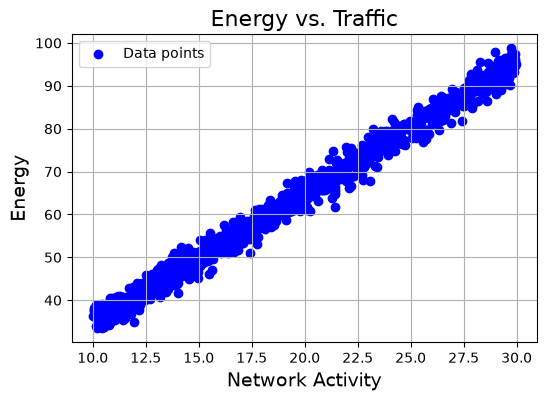

In [48]:
# Load data
data = pd.read_csv('regression.csv')

# Plot the data
plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
plt.legend()
plt.show()

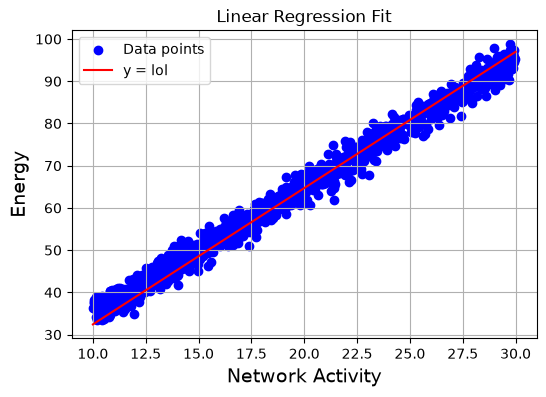

3.2280975724368384
0.1389568021051702


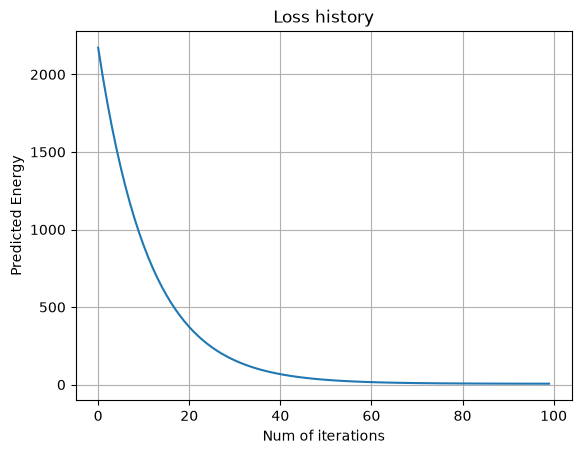

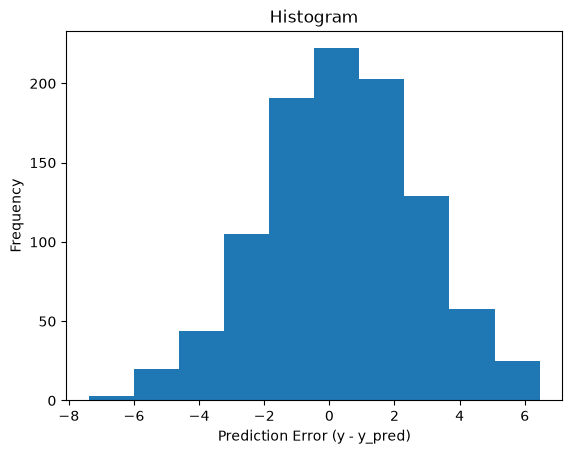

In [49]:
# ====================================
# YOUR CODE GOES HERE
#Før jeg sender dataen inn, pass på at typen til dataen er slik jeg vil ha den


linear_regression = LinearRegression()
linear_regression.fit(data['Net_Activity'], data['Energy'])
y_pred = linear_regression.predict(data['Net_Activity'])

vekt = linear_regression.weights
bias = linear_regression.bias

import matplotlib.pyplot as plt

#Tester: Matcher linjen punktene? 
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
vekt_val = vekt.item()   

x_vals = np.arange(10, 31)
y_vals = vekt_val * x_vals + bias
plt.plot(x_vals, y_vals, color='red', label=f'y = lol')

plt.ylabel('Energy', fontsize=14)
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

print(vekt_val)
print(bias)

#Trainng loss curve
plt.plot(linear_regression.loss_history[:100])
plt.xlabel('Num of iterations')
plt.ylabel('Predicted Energy')
plt.title('Loss history')
plt.grid(True)
plt.show()

#Error distribution
y = np.asarray(data['Energy'])
error = y - y_pred
plt.hist(error)
plt.xlabel('Prediction Error (y - y_pred)')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()
#print(np.mean(error))

# ====================================

### ❓ Is the training loss curve stable?

The training curve is stable as itgoes smoothly downward and flattens out. There are not sudden spikes.  

### ❓ Derive the resulting energy consumption formula
f(x) = 3.2280975724368384*x + 0.1389568021051702

### ❓ Analyze prediction error distribution. What is an unbiased estimator?
Negative numbers: The model over-predicted. 
Postivive numbers: The model under-predicted.
An unbiased estimator: its expected value equals the true value of the parameter it's estimating:


### ❓ What does it tell you when the gradient in SGD is close to zero?
Stochastic Gradient Descent is an ptimization algorithm. In contrast to trdaitional gradient decent that computes the gradients based on the entire dataset (computaionally expensive), the gradients are calculated for the traning examples (small subset of examples) instead of the enire dataset. 
When it is close to zero, it means that the model parameters have converged to an optimal solution. The learning process is then nearing completion. 
 

## 🔋 Problem 2: Logistic regression

### Your task
1. Implement logistic regression
2. Train your model on binary classification data
3. Engineer features to improve the model's performance

### Formal requirements
1. **Implementation**:
   - Same as before, use standard libraries
   - Implement gradient descent

2. **Performance**: Achieve at least **0.88** classification accuracy on the test set

3. **Discussion**:
   - Explain poor initial performance and your improvements
   - What is the model's inductive bias. Why is it important?
   - Plot the ROC curve, what does the area under the curve measure?

In [50]:
data = pd.read_csv('classification.csv')
train = data[data['split'] == 'train'] #hent data som bare er markert som train
test = data[data['split'] == 'test'] #data markert som test

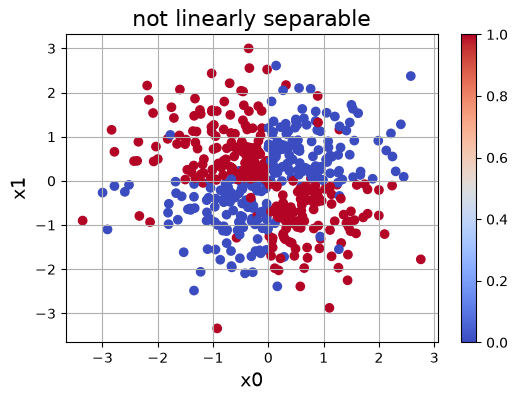

In [51]:
# visualize x0 and x1 of train on scatterplot with colors corresponding to y
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('not linearly separable', fontsize=16)
plt.colorbar()
plt.show()

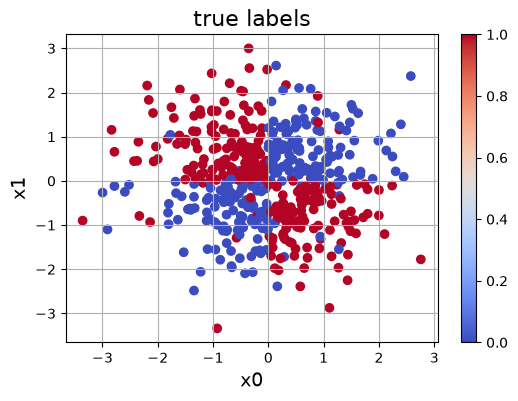

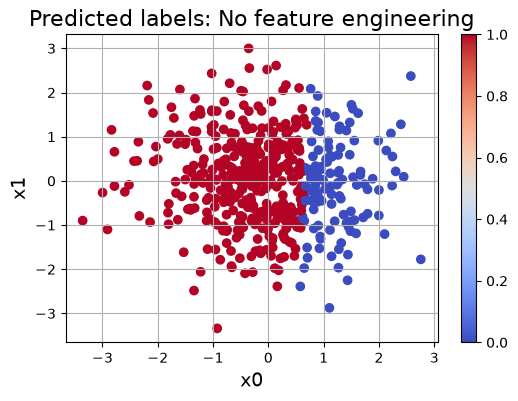

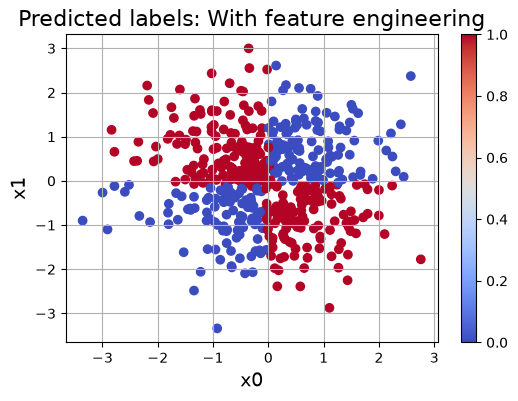

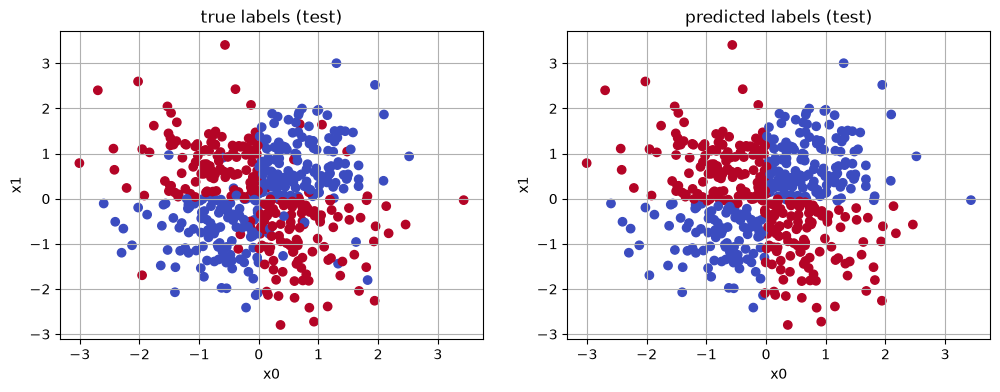

Train accuracy: 0.910
Test accuracy:  0.900


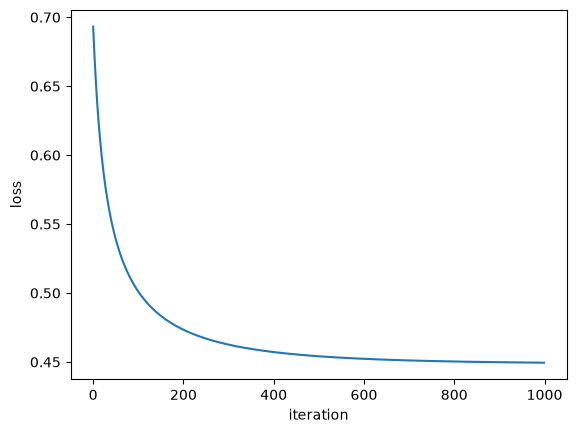

In [52]:
# ====================================
# YOUR CODE GOES HERE 
X = train[['x0', 'x1']]   # kombinerer inn til en (m, 2) feature matrix
y = train['y']

logistic_regression = LogisticRegression()
logistic_regression.fit(X, y)
y_pred = logistic_regression.predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('true labels', fontsize=16)
plt.colorbar()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=y_pred, cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Predicted labels: No feature engineering', fontsize=16)
plt.colorbar()
plt.show()

#Imporved prediction
#Beholde at modellen sugde, lage x mod og y mod
#husk å modifided 

train['x2'] = train['x0'] * train['x1']

X = train[['x0', 'x1', 'x2']]
y = train['y']

logistic_regression = LogisticRegression()
logistic_regression.fit(X, y)

train['x2'] = train['x0'] * train['x1']
X = train[['x0', 'x1', 'x2']]
y = train['y']

logistic_regression = LogisticRegression()
logistic_regression.fit(X, y)
y_pred = logistic_regression.predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=y_pred, cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Predicted labels: With feature engineering', fontsize=16)
plt.colorbar()
plt.show()

#Testing av den forbedrede modellen 
# feature engineering on both
train = train.copy()
test = test.copy()
train['x2'] = train['x0'] * train['x1']
test['x2']  = test['x0'] * test['x1']

X_train, y_train = train[['x0', 'x1', 'x2']], train['y']
X_test, y_test   = test[['x0', 'x1', 'x2']], test['y']

# fit on train only
model = LogisticRegression()
model.fit(X_train, y_train)

# predict on both (to check for overfitting)
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(test['x0'], test['x1'], c=y_test, cmap='coolwarm')
axes[0].set_title('true labels (test)')

axes[1].scatter(test['x0'], test['x1'], c=y_pred_test, cmap='coolwarm')
axes[1].set_title('predicted labels (test)')

for ax in axes:
    ax.set_xlabel('x0'); ax.set_ylabel('x1'); ax.grid(True)
plt.show()

print(f"Train accuracy: {model.accuracy(y_train.values, y_pred_train):.3f}")
print(f"Test accuracy:  {model.accuracy(y_test.values, y_pred_test):.3f}")

#Checking the loss history graph
plt.plot(model.loss_history)
plt.xlabel('iteration'); plt.ylabel('loss')
plt.show()

# ====================================

### ❓ Explain poor initial performance and your improvements
The porblem is that the ideal clustering is not linearly separable. Instead of being split in two with one line down the middle, it is split into fours.
In the ideal clustering we can see that pattern that targets where both x0 and x1 are negative or both are positive are mostely blue, while those that have a combination of negative and positive featuers are red. We can then do a feature engineering with x2 = x0*x1. If x2 = + => blue, if x2=- => -. 
### ❓ What is the model's inductive bias? Why is it important?
Inductive bias is the built-in assumption a model makes about the relationship between inputs and outputs. 
The inductive bias for logisctiv regression i that the classes are linearly seperable -> it can take a straight line to separate the two classes in the feature space. It produces decision boundaries in the form of w*x +b =0. 

### ❓ What does the area under the ROC curve measure?
ROC (Receiver Operating Characteristic): A graphical plot that illustrates the performance of a binary classifier model at various threshold values. It shows the trade-off between the true positive rate and the false positive rate. The area under shows how well the mdoel can distinguish between positive cases and negative cases. 
